# MNIST Digits Recognition
## Feedforward Network with 2 Hidden Layers

Uses [Keras](https://keras.io/) with [JAX](https://github.com/jax-ml/jax) as NN engine.


---
## Environment & Libraries

### What is NumPy?
NumPy is the **foundational numerical computing library in Python**. It provides the n-dimensional array (`ndarray`) and efficient mathematical operations on it. It is the de facto standard for working with numerical data in the Python scientific ecosystem.

### What is JAX?
JAX is a **high-performance numerical computing library** developed by Google. Its key features are:
- **Automatic differentiation** (`grad`): computes gradients automatically — essential for training models.
- **JIT compilation** (`jit`): compiles Python functions to XLA to run very fast on CPU, GPU, or TPU.
- **Vectorization** (`vmap`) and **parallelism** (`pmap`): transforms functions to operate over batches of data or multiple devices without rewriting the code.

JAX reimplements the NumPy API (`jax.numpy`) almost identically, but its arrays run on GPU/TPU and support automatic differentiation. Migrating code from NumPy to JAX is often as simple as changing the import.

### What is Keras?
Keras is a **high-level API for building and training neural networks**. Its philosophy is simplicity: it allows defining deep learning models with very few lines of code. Since Keras 3, it is **multi-backend** — it can run on top of TensorFlow, PyTorch, or JAX.

### How they relate

```
NumPy          →   the numerical API standard in Python
   ↓
JAX            →   "NumPy on steroids" + autograd + JIT compilation
   ↓
Keras (JAX backend) →  high-level API that uses JAX under the hood
```

NumPy is the *standard*, JAX is NumPy *powered up for ML*, and Keras is the *friendly interface* that can sit on top of JAX (or other backends) to build neural networks.

---
### What is a TPU? How does it compare to CPU and GPU?

| Feature | CPU | GPU | TPU |
|---|---|---|---|
| Design | General purpose | Graphics / massive parallelism | Exclusively for ML |
| Cores | Few (4–64) but powerful | Thousands (smaller) | Few highly specialized units |
| Strength | Complex logic, sequential tasks | Parallel computation | Matrix multiplication |
| ML use | Preprocessing | General training | Large-scale training |
| Example | Intel i9 | NVIDIA A100 | Google TPU v5e |

A **CPU** does a few things very well (sequential logic). A **GPU** does many things in parallel. A **TPU** does **one thing** — multiply matrices — with extreme efficiency, which happens to be exactly what neural networks need most.

The **TPU v5e-1** used in this notebook is Google's latest generation chip optimized for cost-effective inference and fine-tuning of large models. Even a single chip (v5e-1) provides substantial acceleration over CPU for matrix-heavy workloads like MNIST training.


In [1]:
# Install Jax running on Google/Colab Tensor Processing Units
!pip install "jax[tpu]"

# Install Keras
!pip install keras-cv
!pip install keras-hub
!pip install keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 62.3 MB/s eta 0:00:00


**Note on `jax[tpu]`:** The `[tpu]` suffix is a pip *extra* — it installs additional dependencies needed to communicate with Google's TPU hardware. Without it, JAX would only use the CPU.

**Note on `keras-cv` and `keras-hub`:**
- `keras-cv`: extension with ready-to-use computer vision tools (pretrained models like YOLO, ResNet; image augmentation; object detection).
- `keras-hub`: a repository of pretrained models ready to download and use or fine-tune, similar to Hugging Face.


In [2]:
!pip install pydot
!apt-get install -y graphviz  # also required to draw the graph

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


`pydot` and `graphviz` are needed by `keras.utils.plot_model()` to generate the visual diagram of the network architecture. Keras uses `pydot` as a Python wrapper, and `pydot` calls `graphviz` to actually render the image. The chain is:

```
keras.utils.plot_model()
        ↓
      pydot          ← installed with pip
        ↓
    graphviz         ← installed with apt-get
        ↓
  .png image  ✅
```


In [3]:
# Import installed software and put things in place
import os
os.environ["KERAS_BACKEND"] = "jax"
import matplotlib.pyplot as plt
import numpy as np
from keras import layers
from keras import ops
import keras
# print(keras.__version__)
# print(keras.backend.backend())

**Key line:** `os.environ["KERAS_BACKEND"] = "jax"` must be set **before** importing Keras. This tells Keras to use JAX as its compute engine instead of TensorFlow or PyTorch.


In [4]:
print(keras.__version__)
print(keras.backend.backend())  # should print "jax"

import jax
print(jax.devices())            # should show TPU v5e cores

3.13.2
jax
[CudaDevice(id=0)]


---
## Model `model` — Feedforward Network with 2 Hidden Layers

### What is a Feedforward Network?
A **feedforward network** (also called a multilayer perceptron or MLP) is the simplest type of neural network: information flows in **one direction only** — from input to output, with no loops or memory.

```
Input (784)  →  Hidden Layer 1 (64)  →  Hidden Layer 2 (64)  →  Output (10)
```

This contrasts with other architectures:

| Type | Key Feature | Typical Use |
|---|---|---|
| **Feedforward (this one)** | Unidirectional flow | Simple classification |
| **CNN** (Convolutional) | Detects spatial patterns | Images |
| **RNN** (Recurrent) | Has memory of previous steps | Text, time series |
| **LSTM** | Improved RNN, long memory | Translation, audio |
| **Transformer** | Attention between all elements | LLMs (GPT, Claude) |

For MNIST, a feedforward network works well because individual pixels carry enough information. For more complex images, a CNN would be much better because it exploits the **spatial structure** of the image.

---

### What is ReLU?
**ReLU** (Rectified Linear Unit) is an **activation function** that introduces non-linearity into the network:

```
ReLU(x) = max(0, x)

ReLU(-5) = 0
ReLU( 0) = 0
ReLU( 3) = 3
ReLU( 7) = 7
```

Visually:
```
output
  |          /
  |         /
  |        /
  |_______/_________ input
         0
```

**Why is it needed?** Without activation functions, stacking multiple Dense layers would be mathematically equivalent to a single linear transformation — no matter how many layers you add. ReLU breaks this linearity, allowing the network to learn complex patterns.

---

### What is a "logit"?
A **logit** is a raw, unconstrained output value from the network — a real number with no restriction on range (can be negative, zero, or greater than 1). Logits are the direct output of the last Dense layer **before** any normalization.

To convert logits into probabilities, we apply **softmax**:
```
softmax([2.0, 1.0, 0.5])  →  [0.59, 0.24, 0.17]   (they sum to 1.0)
```

In this model, we output logits directly and let the loss function handle the softmax internally (that's what `from_logits=True` means later).

---

### Architecture & Parameter Count

- **Input layer:** 784 neurons (one per pixel of a flattened 28×28 image)
- **Hidden layer 1:** 64 neurons + ReLU → each of the 64 neurons has 784 weights + 1 bias = 785 params → **64 × 785 = 50,240 params**
- **Hidden layer 2:** 64 neurons + ReLU → each has 64 weights + 1 bias = 65 params → **64 × 65 = 4,160 params**
- **Output layer:** 10 neurons (one per digit 0–9) → each has 64 weights + 1 bias = 65 params → **10 × 65 = 650 params**

**Total: 50,240 + 4,160 + 650 = 55,050 parameters**

> **Note:** The MNIST data set has *not* yet been loaded at all! Absolutely *no* data has been used at this point. The model architecture is defined independently of the data.


In [5]:
dim_hl_1 = 64 # @param {type: "integer"}
dim_hl_2 = 64 # @param {type: "integer"}

inputs = keras.Input(shape=(784,))  # Input layer shape for flatened MNIST images
hidden1 = layers.Dense(dim_hl_1, activation="relu")(inputs)  # First hidden layer
hidden2 = layers.Dense(dim_hl_2, activation="relu")(hidden1)  # Second hidden layer
# Output layer must have dimension 10 = number of categories.
outputs = layers.Dense(10)(hidden2)  # No ReLu here b/c output is "logits".
model = keras.Model(inputs=inputs, outputs=outputs, name="mnist_model")
model.summary()

Model: "mnist_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

**What does a Keras model look like as a Python object?**

A Keras model is an instance of the class `keras.Model`. After creation, it exposes useful attributes:

```python
model.layers        # list of all layers
model.weights       # all trainable parameters (as tensors)
model.trainable     # whether parameters can be updated
model.optimizer     # optimization algorithm (after compile)
model.loss          # loss function (after compile)
```

Each Dense layer internally stores two tensors:
```python
layer = model.layers[1]
layer.kernel  # weight matrix, shape (784, 64)
layer.bias    # bias vector, shape (64,)
```

The `None` dimension in shapes like `(None, 784)` represents the **batch size** — the number of images processed at once. It is `None` because the model accepts any number:
- 1 image   → `(1, 784)`
- 32 images → `(32, 784)`
- 1000 images → `(1000, 784)`


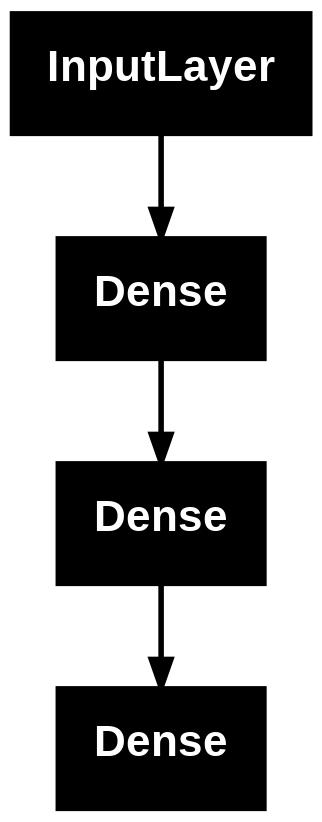

In [6]:
keras.utils.plot_model(model, "feedforward_model.png")

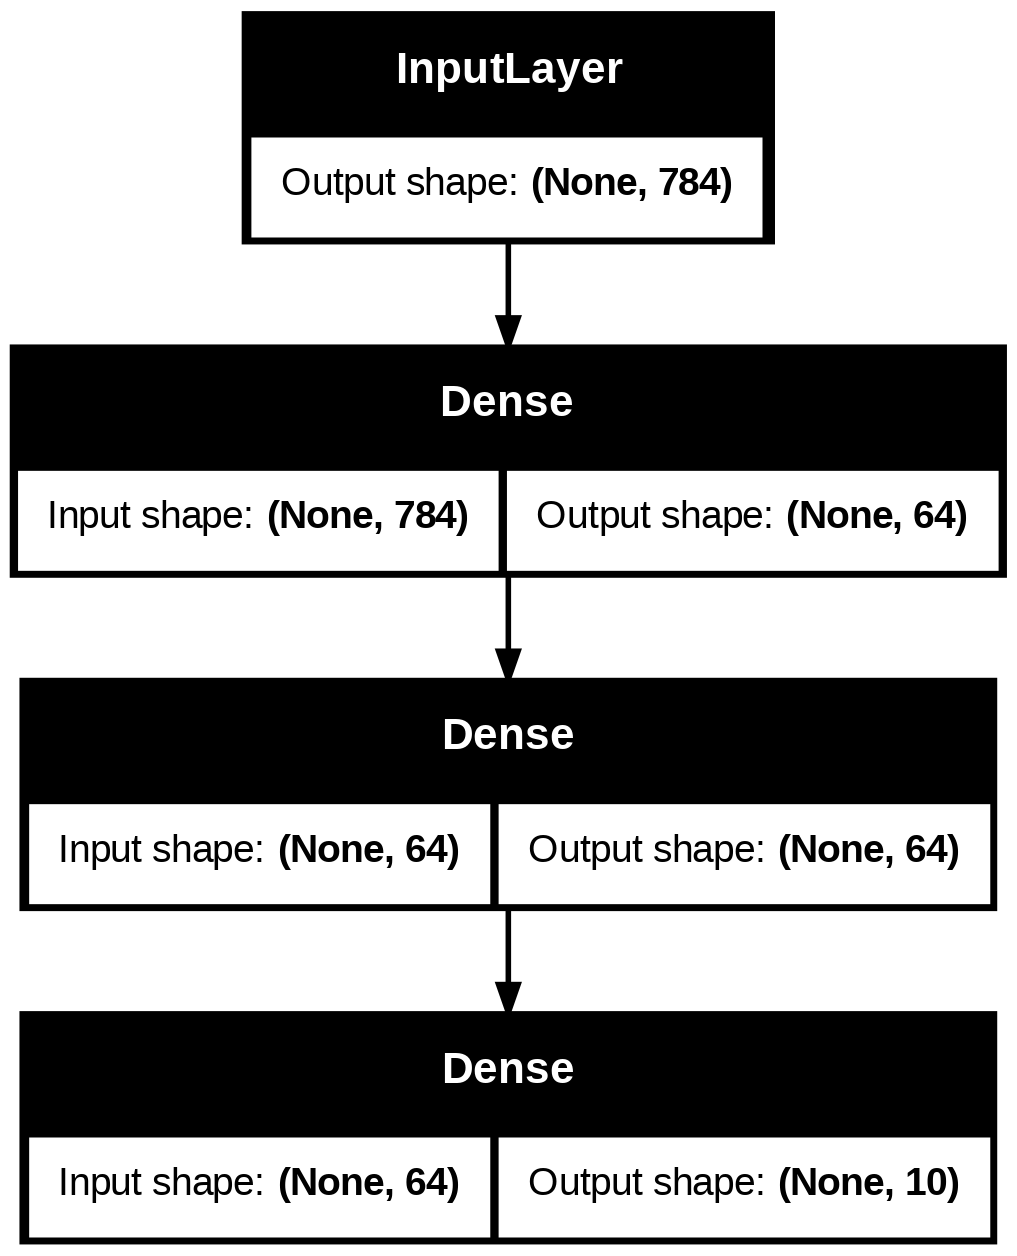

In [7]:
keras.utils.plot_model(model, "feedforward_model_with_shape_info.png", show_shapes=True)

---
## Load MNIST Dataset

### What is MNIST?
MNIST (*Modified National Institute of Standards and Technology*) is the classic **handwritten digit recognition dataset** — the "Hello World" of machine learning. Created in 1998 by Yann LeCun, Corinna Cortes, and Christopher Burges.

**Contents:**
- 70,000 grayscale images total
  - 60,000 for training
  - 10,000 for testing
- Each image: **28×28 pixels**
- Each image has a **label** from 0 to 9

**Why is it so popular?**
- Small and fast to train (works well on CPU)
- Perfectly balanced (same number of each digit)
- It is a "solved" problem, so it serves to verify that a new model works correctly before tackling more complex problems

---

### What is `float32`? How are 32 bits used to store real numbers?

`float32` follows the **IEEE 754** standard and distributes its 32 bits as follows:

```
 1 bit        8 bits           23 bits
   │             │                │
 sign        exponent          mantissa
 (+/-)       (magnitude)       (precision)
```

Example — the number `0.5`:
```
0  01111110  00000000000000000000000
+     -1           1.0
result: +1.0 × 2^(-1) = 0.5
```

- Can represent numbers from ~`1.2 × 10⁻³⁸` to ~`3.4 × 10³⁸`
- About 7 decimal digits of precision
- It is the standard in deep learning: balances precision and speed better than `float64`

---

### Other Numeric Types Supported by NumPy

| Type | Bits | Typical Use |
|---|---|---|
| `float16` | 16 | GPU training (faster, less precise) |
| `float32` | 32 | **Deep learning standard ← used here** |
| `float64` | 64 | General scientific computation |
| `int8` | 8 | Quantized models (fast inference) |
| `int32` | 32 | Indices, labels |
| `uint8` | 8 | Raw pixel values (0–255) ← original MNIST format |
| `bool` | 8 | Logical masks |

---

Each single MNIST image of a handwritten digit 0, 1, 2, …, 8, 9 is encoded as a matrix of size `28*28` whose entries are 8-bit unsigned integers (i.e., each entry is an integer in the range from `0` to `2^8 - 1 = 255`). Each integer represents the grayscale color of a pixel (0 = black, 255 = white).

For reasons of computational efficiency and numerical stability, the grayscale is rescaled to be a floating-point (decimal) number in the interval `[0, 1)`, and the 28-by-28 matrix is "flattened" to be a single (column) vector of `28*28 = 784` decimal such entries, each a `float32` (32-bit floating point number).

Since the training set consists of 60,000 such digit images, each effectively a column vector of size 784, it gives a large matrix `x_train` of size `60,000 × 784`; similarly, the test set of 10,000 images gives a `10,000 × 784` matrix `x_test`.


In [8]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.reshape(60000, 784).astype("float32") / 255
x_test = x_test.reshape(10000, 784).astype("float32") / 255

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Three things in one line:**
1. `.reshape(60000, 784)` — flattens each 28×28 image into a 784-element vector: `(60000, 28, 28) → (60000, 784)`
2. `.astype("float32")` — converts pixels from integers (`uint8`) to 32-bit decimals
3. `/ 255` — normalizes values to the range `[0, 1]`: `0 → 0.0`, `128 → 0.50`, `255 → 1.0`

**Final data state:**
```
x_train:  (60000, 784)  float32  values between 0.0 and 1.0
y_train:  (60000,)      int      values between 0 and 9
x_test:   (10000, 784)  float32  values between 0.0 and 1.0
y_test:   (10000,)      int      values between 0 and 9
```


---
## Compile and Train the Model

### Training, Validation, and Test Sets — What is the Difference?

```
Full Dataset (70,000 MNIST images)
├── Training set  (48,000) ← the model LEARNS from these
├── Validation set (12,000) ← evaluated during training to detect problems
└── Test set      (10,000) ← final evaluation, NEVER seen during training
```

| Set | When Used | Purpose |
|---|---|---|
| **Training** | During each epoch | Adjust the parameters (weights) |
| **Validation** | At the end of each epoch | Detect overfitting |
| **Test** | Only once at the very end | Measure real-world performance |

**The key rule:** the model never learns from the test data. If it did, you would be measuring memorization, not real generalization.

**What is overfitting?** When `train` accuracy keeps improving but `val` accuracy stagnates or drops — the model is memorizing training examples instead of learning general patterns.

---

### What is Categorical Cross-Entropy?

The **loss function** measures how wrong the model's predictions are. Categorical cross-entropy compares the predicted probability distribution against the true label:

```
If the true digit is 3:
  true distribution:      [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
  predicted distribution: [0.01, 0.01, 0.01, 0.90, ...]

  loss = -log(0.90) ≈ 0.10  ← low, good prediction ✅

  if predicted wrong:
  predicted distribution: [0.01, 0.01, 0.01, 0.05, ...]
  loss = -log(0.05) ≈ 3.0   ← high, bad prediction ❌
```

A larger loss means less accuracy. The goal during training is to **minimize** the loss.

`SparseCategoricalCrossentropy` is used when labels are plain integers (0, 1, 2… 9) rather than one-hot vectors. `from_logits=True` tells the function that the output layer produces raw logits (no softmax applied yet) — it handles the conversion internally, which is numerically more stable.

---

### What is RMSprop? How Does it Compare to Other Optimizers?

An optimizer decides **how to adjust the parameters** to reduce the loss. All are variants of gradient descent:

```
new_parameter = old_parameter - learning_rate × gradient
```

| Optimizer | Core Idea | Advantage |
|---|---|---|
| **SGD** | Simple gradient | Simple, predictable |
| **Momentum** | Accumulates velocity in the right direction | Faster than SGD |
| **RMSprop** | Adapts learning rate per parameter based on history | Stable in deep networks |
| **Adam** | Combines Momentum + RMSprop | Most widely used in practice |
| **Adagrad** | Reduces rate for frequent parameters | Good for sparse data |

**RMSprop** specifically divides the learning rate by a moving average of the recent squared gradients, preventing some parameters from updating too fast and others too slow. It was proposed by Geoffrey Hinton and is especially stable for recurrent networks.

---

By default, when a model is "compiled", its parameters are initialized randomly and uniformly (with zero mean and variance determined by the input and output dimensions at each layer — but otherwise not of immediate interest to us right now).

When `model` is applied to an input of size `m × 784`, it is applied to *each* of the `m` rows, one at a time — because `model` only accepts as input a (column) vector of size 784, and outputs one of size 10; in other words, `model` sees those `m` *rows* as completely independent of each other. The result is a matrix of size `m × 10`.

`batch_size=64` means that each "training step" of the model uses *only* a randomly-chosen batch of (about) `m = 64` inputs (i.e., 64 rows of `x_train`) at a time, until all 60,000 rows are exhausted. This is called a (single) "epoch", which consists of (about) `60,000/64 ≈ 934` such steps. The process is restarted and carried out a total number of epochs `num_epochs = 20`.

(Actually, `validation_split=0.2` means that 20% of the training data is excluded during each epoch, so an epoch therefore only consists of about `0.8 * 934 ≈ 747` batches of `≈ 64` training images each.)

Keras has various built-in optimization algorithms; this model's algorithm is the *root mean-square propagation* or `RMSprop`.

The accuracy of the model is quantified using a "loss" function. A larger loss means less accuracy, so the goal as the model is trained is *reducing* or "minimizing" the loss. (The loss function used in this implementation is called *categorical cross-entropy*. Entropy and related quantities will be introduced later in the semester.)


In [9]:
num_epochs = 20  # @param {type: "integer"}

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

history = model.fit(x_train, y_train, batch_size=64, epochs=20, validation_split=0.2)

# Fix: verbose should be an integer, not a string
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9011 - loss: 0.3494 - val_accuracy: 0.9402 - val_loss: 0.2047
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9505 - loss: 0.1661 - val_accuracy: 0.9560 - val_loss: 0.1474
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9640 - loss: 0.1195 - val_accuracy: 0.9680 - val_loss: 0.1119
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9720 - loss: 0.0936 - val_accuracy: 0.9661 - val_loss: 0.1137
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9768 - loss: 0.0787 - val_accuracy: 0.9735 - val_loss: 0.0968
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9806 - loss: 0.0661 - val_accuracy: 0.9739 - val_loss: 0.0923
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9832 - loss: 0.0567 - val_accuracy: 0.9726 - val_loss: 0.0985
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9854 - loss: 0.0491 - val_accuracy: 0.

---
## Visualizing Training Progress

The `history` object stores metrics recorded at the end of each epoch. We plot:
- `accuracy` vs `val_accuracy`: how well the model classifies training vs. validation images
- `loss` vs `val_loss`: how much error the model makes on training vs. validation data

**What to look for:**
- ✅ **Good:** both lines improve together and stabilize
- ⚠️ **Overfitting:** `train` keeps improving but `val` stagnates or gets worse
- ⚠️ **Underfitting:** both lines stagnate at high loss / low accuracy


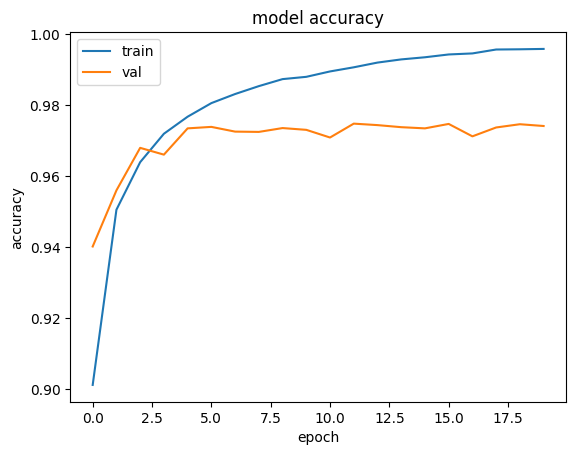

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

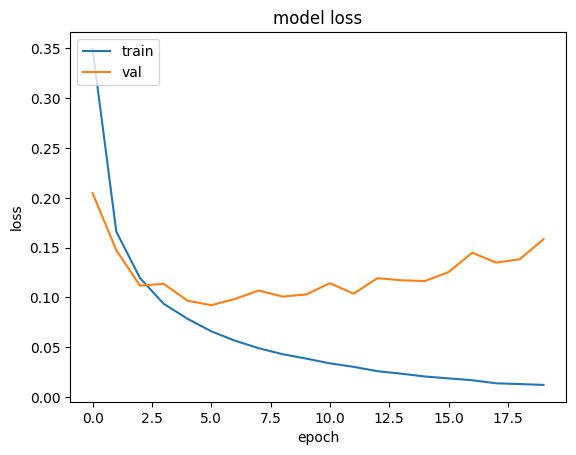

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

---
## Sample Predictions

The code below randomly chooses 5 of the 10,000 images in the test set and applies `model` to assign a label (0, 1, …, 9) using a straightforward **likelihood maximization** procedure (i.e., `argmax` of the output logits — pick the digit with the highest score). Very few images in the test set should be misclassified: the `True` and `Pred`icted labels should be in agreement.

With ~97% accuracy, on average only 1 in ~37 images is misclassified — so in a sample of 5, most likely all 5 will be correct. Errors that do occur tend to be *reasonable mistakes* (e.g., a 9 written in a way that looks like a 3), not arbitrary ones.


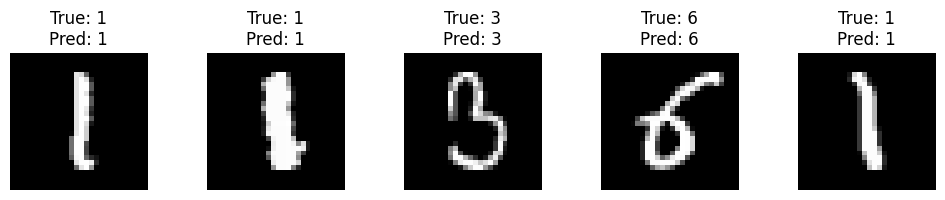

In [12]:
# Select a few random indices from the test set
num_samples = 5
indices = np.random.choice(len(x_test), num_samples, replace=False)

plt.figure(figsize=(10, 2))
for i, idx in enumerate(indices):
    img = x_test[idx]
    # If images are flattened, reshape to 28x28
    if img.shape[-1] != 28:
        img = img.reshape(28, 28)
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    # Predict label and compare with true label.
    pred = model.predict(np.expand_dims(x_test[idx], axis=0), verbose=0)
    pred_label = np.argmax(pred, axis=1)[0]
    true_label = y_test[idx]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
plt.tight_layout()
plt.show()

---
---
# Concepts Investigation

*There are likely at least some new and unfamiliar concepts present in the code or implied by it. This section analyzes and explains them — not simply copied and pasted, but understood and re-expressed.*

---

## 1. What is a TPU? What are its similarities and differences with a CPU and a GPU?

A **CPU** (Central Processing Unit) is a general-purpose chip designed for sequential, complex logic. It has a small number of powerful cores (typically 4–64) optimized for tasks that require branching, memory access, and control flow.

A **GPU** (Graphics Processing Unit) was originally designed for rendering graphics, which requires processing millions of pixels in parallel. This made it ideal for neural networks, which also involve massive parallelism — multiplying large matrices simultaneously across thousands of smaller cores.

A **TPU** (Tensor Processing Unit) is a chip designed by Google from the ground up for a single purpose: **matrix multiplication**, which is the core operation in every layer of every neural network. Unlike CPUs and GPUs which are general-purpose, a TPU is purpose-built for the one operation that dominates ML workloads.

| Feature | CPU | GPU | TPU |
|---|---|---|---|
| Design goal | General purpose | Parallel graphics | Matrix multiply for ML |
| Core count | Few, powerful | Thousands, smaller | Few, ultra-specialized |
| Clock speed | High | Medium | Lower |
| Memory type | DRAM | GDDR / HBM | HBM (High Bandwidth Memory) |
| Best for | Preprocessing, control flow | General training | Large-scale training |
| Programming | Python, C, any language | CUDA (NVIDIA) | XLA (via JAX/TF) |

The **TPU v5e** used in this notebook is Google's latest generation, optimized for cost-effective inference and fine-tuning.

---

## 2. What is Keras? What is JAX? What is NumPy? How do they relate?

**NumPy** is the foundational numerical computing library in Python. It defines the standard n-dimensional array (`ndarray`) interface and mathematical operations on it. It is so widely used that it has become the lingua franca of scientific Python.

**JAX** reimplements the NumPy API (`jax.numpy`) almost identically, but adds three superpowers: automatic differentiation (`grad`), JIT compilation to XLA (`jit`), and automatic vectorization (`vmap`). The result is that JAX arrays can run on GPUs and TPUs at near-hardware speed, while still being differentiable — exactly what training neural networks requires.

**Keras** is a high-level API for defining, training, and evaluating neural networks. Since Keras 3, it is *backend-agnostic*: the same Keras code can run on top of JAX, TensorFlow, or PyTorch. In this notebook, we set `KERAS_BACKEND = "jax"`, so every Keras operation ultimately executes as a JAX computation on the TPU.

The hierarchy: NumPy defines the standard → JAX accelerates and differentiates it → Keras wraps it in a clean modeling API.

---

## 3. What is `float32`? How are those 32 bits used to store real numbers?

`float32` follows the **IEEE 754 single-precision floating-point standard**. The 32 bits are divided into three fields:

```
 Bit 31     Bits 30–23      Bits 22–0
   │             │               │
 sign (1)   exponent (8)   mantissa (23)
```

The value represented is: `(-1)^sign × 2^(exponent - 127) × (1 + mantissa/2^23)`

- **Sign bit:** 0 = positive, 1 = negative
- **Exponent:** a biased integer (bias = 127) determining the magnitude
- **Mantissa:** the fractional precision bits

This gives a range of approximately `±3.4 × 10^38` with about 7 significant decimal digits of precision.

`float32` is the deep learning standard because it offers enough precision for gradient-based training while being twice as compact as `float64`, which means faster computation and less memory usage on GPU/TPU.

---

## 4. What other float and numeric types does NumPy support?

| Type | Bits | Range / Precision | Typical Use |
|---|---|---|---|
| `float16` | 16 | ~3.3 × 10^4, ~3 digits | Mixed-precision GPU training |
| `float32` | 32 | ~3.4 × 10^38, ~7 digits | **DL standard** |
| `float64` | 64 | ~1.8 × 10^308, ~15 digits | Scientific computing |
| `float128` | 128 | Extended precision | Rarely used |
| `int8` | 8 | –128 to 127 | Quantized inference |
| `int16` | 16 | –32,768 to 32,767 | Audio, embedded |
| `int32` | 32 | –2.1B to 2.1B | Indices, labels |
| `int64` | 64 | –9.2 × 10^18 to 9.2 × 10^18 | Large counts |
| `uint8` | 8 | 0 to 255 | **Raw pixel values (MNIST input)** |
| `bool` | 8 | True / False | Logical masks |
| `complex64` | 64 | Two float32s | Signal processing |

---

## 5. What does a Keras model actually consist of? What does it look like as a Python object?

A Keras model is an instance of `keras.Model`. It is a Python object with attributes and methods like any other class, but its internal computations execute on the chosen backend (here, JAX on TPU).

Key attributes after creation:
```python
model.layers         # list of Layer objects
model.weights        # list of all trainable weight tensors
model.trainable      # bool: whether weights can be updated
model.input_shape    # shape expected at input
model.output_shape   # shape produced at output
```

After `compile`:
```python
model.optimizer      # e.g. RMSprop instance
model.loss           # e.g. SparseCategoricalCrossentropy instance
model.metrics        # e.g. [Accuracy]
```

After `fit`:
```python
model.history        # dict with 'loss', 'accuracy', 'val_loss', 'val_accuracy' per epoch
```

Each Dense layer internally stores two tensors:
```python
dense_layer.kernel   # weight matrix W, shape (input_dim, output_dim)
dense_layer.bias     # bias vector b, shape (output_dim,)
```

The computation of one layer is simply: `output = ReLU(input @ W + b)`

---

## 6. What is a "logit"? What is "ReLU"? What is "categorical cross-entropy"?

**Logit:** a raw, unconstrained output value from the network — a real number that can be negative, zero, or greater than 1. Logits are the direct outputs of the final Dense layer before any normalization. To turn logits into a probability distribution, we apply *softmax*: `softmax(x_i) = exp(x_i) / Σ exp(x_j)`, which ensures all values are positive and sum to 1.

**ReLU** (Rectified Linear Unit): an activation function defined as `f(x) = max(0, x)`. It is applied after each hidden layer to introduce non-linearity. Without non-linearity, any number of stacked linear (Dense) layers would collapse into a single linear transformation, severely limiting what the network can learn.

**Categorical cross-entropy:** a loss function that measures the dissimilarity between the predicted probability distribution and the true label. For a single example where the true class is `c` and the model assigns probability `p_c` to that class: `loss = -log(p_c)`. If the model is very confident and correct (high `p_c`), the loss is near zero. If the model assigns low probability to the correct class, the loss is large. `SparseCategoricalCrossentropy` is the variant used when labels are integers rather than one-hot vectors.

---

## 7. What other datasets beyond MNIST are widely used as NN benchmarks?

| Dataset | Content | Task | Scale |
|---|---|---|---|
| **MNIST** | Handwritten digits | 10-class classification | 70K images |
| **Fashion-MNIST** | Clothing items | 10-class classification | 70K images |
| **CIFAR-10** | 10 object categories | Classification | 60K images |
| **CIFAR-100** | 100 object categories | Fine-grained classification | 60K images |
| **ImageNet** | 1000+ object categories | Classification, detection | 1.2M images |
| **COCO** | Annotated objects in scenes | Detection, segmentation | 330K images |
| **IMDB** | Movie reviews | Sentiment analysis | 50K reviews |
| **WikiText** | Wikipedia text | Language modeling | 100M+ tokens |
| **SQuAD** | Wikipedia Q&A pairs | Reading comprehension | 100K questions |
| **LibriSpeech** | Audiobook recordings | Speech recognition | 1000 hours |

MNIST is to deep learning what "Hello World" is to programming — the first sanity check for any new model or framework.

---

## 8. What is the difference between training, validation, and test sets?

When building a machine learning model, data is split into three non-overlapping subsets:

**Training set** (here: 80% of 60K = 48,000 images): the data the model actually *learns from*. Weights are updated using gradients computed on this data.

**Validation set** (here: 20% of 60K = 12,000 images): held out during training but evaluated at the end of each epoch. It serves as an early warning system for *overfitting* — if training accuracy keeps rising but validation accuracy plateaus or drops, the model is memorizing rather than generalizing.

**Test set** (here: 10,000 images): completely separate from the training process. Evaluated only once, at the very end. It gives an unbiased estimate of how the model will perform on new, unseen data in the real world.

The critical rule: **the model never sees the test set during training or hyperparameter tuning**. If you use test set performance to make decisions (e.g., "let me add more layers since my test accuracy was low"), the test set is no longer truly independent and your final accuracy estimate becomes optimistic.

---

## 9. What is the difference between a feedforward network and other types of neural networks?

A **feedforward network** processes information in a single direction: input → hidden layers → output. There are no cycles, no memory, no feedback. Each input is processed independently.

Other architectures extend this in different ways:

**Convolutional Neural Networks (CNNs):** instead of connecting every neuron to every other, use small local filters that slide over the input. This exploits spatial locality — nearby pixels in an image tend to be related. Much more parameter-efficient and accurate than feedforward nets for image tasks.

**Recurrent Neural Networks (RNNs):** have a feedback loop — the output of one step becomes part of the input to the next. This gives the network a form of memory over sequences, making them suitable for text and time-series data.

**LSTMs and GRUs:** improvements to RNNs that address the "vanishing gradient" problem, allowing them to remember information over longer sequences.

**Transformers:** the current dominant architecture for language (and increasingly vision). They use *self-attention* — every element in the sequence can directly interact with every other element — achieving both long-range memory and parallelizable training.

For MNIST, a feedforward network suffices because classifying a digit from its raw pixels is a relatively simple mapping. For natural images, language, or audio, more specialized architectures are required.

---

## 10. What is Root Mean Square Propagation (RMSprop)? How does it compare to other optimization methods?

All neural network optimizers are variants of **gradient descent**: at each training step, compute how the loss changes with respect to each parameter (the gradient), then move the parameters slightly in the direction that decreases the loss.

The simplest version, **SGD** (Stochastic Gradient Descent), applies the same learning rate to all parameters at every step. This can be slow or unstable when gradients vary widely across parameters.

**Momentum** improves on SGD by accumulating a velocity vector in the gradient direction, allowing faster traversal of flat regions and dampening oscillations.

**RMSprop**, proposed by Geoffrey Hinton, maintains a per-parameter moving average of squared gradients and divides the learning rate by the square root of this average. This *adapts* the learning rate: parameters with consistently large gradients get a smaller effective learning rate; parameters with small gradients get a larger one. The result is more stable training, especially in deep networks with inconsistent gradient scales.

**Adam** (Adaptive Moment Estimation) combines both momentum and RMSprop: it tracks both the first moment (mean of gradients) and the second moment (mean of squared gradients). Adam is currently the most widely used optimizer due to its robustness across many problem types.

| Optimizer | Adapts LR? | Uses Momentum? | Typical Use |
|---|---|---|---|
| SGD | No | No | Simple tasks, final fine-tuning |
| SGD + Momentum | No | Yes | Image classification |
| RMSprop | Yes | No | RNNs, this notebook |
| Adam | Yes | Yes | Most DL tasks |
| Adagrad | Yes (cumulative) | No | Sparse data, NLP |
